<a href="https://colab.research.google.com/github/karthiksenthil742/Sales-Forecasting/blob/main/predictive_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

# Change this path if your dataset is inside a different folder
dataset_path = "/content/drive/MyDrive/forecasting dataset"

print("Files available in the dataset folder:\n")

for file in os.listdir(dataset_path):
    print(file)

Files available in the dataset folder:

superstore_sales_dataset.zip
extracted_data


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/forecasting dataset/superstore_sales_dataset.zip"

extract_path = "/content/drive/MyDrive/forecasting dataset/extracted_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!\n")

print("Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Dataset extracted successfully!

Extracted files:
/content/drive/MyDrive/forecasting dataset/extracted_data/train.csv


In [4]:
import pandas as pd

# Dataset path
file_path = "/content/drive/MyDrive/forecasting dataset/extracted_data/train.csv"

# Load dataset
df = pd.read_csv(file_path)

print("========== DATASET OVERVIEW ==========\n")

print("Dataset Shape:")
print(df.shape)

print("\n========== COLUMN NAMES ==========\n")
print(df.columns.tolist())

print("\n========== FIRST 5 ROWS ==========\n")
display(df.head())

print("\n========== DATA TYPES ==========\n")
print(df.dtypes)

print("\n========== DATASET INFORMATION ==========\n")
df.info()

========== DATASET OVERVIEW ==========

Dataset Shape:
(9800, 18)

========== COLUMN NAMES ==========

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

========== FIRST 5 ROWS ==========



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



========== DATA TYPES ==========

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

========== DATASET INFORMATION ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object

In [5]:
print("========== DATA QUALITY CHECK ==========\n")

# 1. Missing Values
print("1. MISSING VALUES:\n")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 2. Duplicate Rows
print("\n2. DUPLICATE ROWS:")
print(df.duplicated().sum())

# 3. Duplicate Order IDs
print("\n3. DUPLICATE ORDER IDs:")
print(df["Order ID"].duplicated().sum())

# 4. Numerical Summary
print("\n========== NUMERICAL SUMMARY ==========\n")
display(df.describe())

# 5. Sales Validation
print("\n========== SALES VALIDATION ==========\n")

print("Negative Sales:", (df["Sales"] < 0).sum())
print("Zero Sales:", (df["Sales"] == 0).sum())

print("\nMinimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())

# 6. Unique Values
print("\n========== UNIQUE VALUES ==========\n")

columns_to_check = [
    "Ship Mode",
    "Segment",
    "Country",
    "Region",
    "Category",
    "Sub-Category"
]

for column in columns_to_check:
    print(f"{column}: {df[column].nunique()} unique values")

========== DATA QUALITY CHECK ==========

1. MISSING VALUES:

Postal Code    11
dtype: int64

2. DUPLICATE ROWS:
0

3. DUPLICATE ORDER IDs:
4878

========== NUMERICAL SUMMARY ==========



,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000



========== SALES VALIDATION ==========

Negative Sales: 0
Zero Sales: 0

Minimum Sales: 0.444
Maximum Sales: 22638.48

========== UNIQUE VALUES ==========

Ship Mode: 4 unique values
Segment: 3 unique values
Country: 1 unique values
Region: 4 unique values
Category: 3 unique values
Sub-Category: 17 unique values


In [6]:
# Create a copy of the original dataset
df_clean = df.copy()

print("========== DATA CLEANING ==========\n")

# Convert date columns to datetime
df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    dayfirst=True,
    errors="coerce"
)

df_clean["Ship Date"] = pd.to_datetime(
    df_clean["Ship Date"],
    dayfirst=True,
    errors="coerce"
)

# Check invalid dates after conversion
print("Invalid Order Dates:", df_clean["Order Date"].isnull().sum())
print("Invalid Ship Dates:", df_clean["Ship Date"].isnull().sum())

# Sort dataset chronologically
df_clean = df_clean.sort_values("Order Date").reset_index(drop=True)

# Check date range
print("\n========== DATE RANGE ==========\n")
print("Start Date:", df_clean["Order Date"].min())
print("End Date:", df_clean["Order Date"].max())

# Final quality check
print("\n========== CLEANING SUMMARY ==========\n")
print("Rows:", len(df_clean))
print("Duplicate Rows:", df_clean.duplicated().sum())
print("Missing Order Dates:", df_clean["Order Date"].isnull().sum())
print("Missing Sales:", df_clean["Sales"].isnull().sum())

print("\nDataset cleaned and prepared successfully! 🔥")

========== DATA CLEANING ==========

Invalid Order Dates: 0
Invalid Ship Dates: 0

========== DATE RANGE ==========

Start Date: 2015-01-03 00:00:00
End Date: 2018-12-30 00:00:00

========== CLEANING SUMMARY ==========

Rows: 9800
Duplicate Rows: 0
Missing Order Dates: 0
Missing Sales: 0

Dataset cleaned and prepared successfully! 🔥


In [7]:
# Create daily sales time series
daily_sales = (
    df_clean
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

# Rename columns for clarity
daily_sales.columns = ["Date", "Sales"]

# Sort chronologically
daily_sales = daily_sales.sort_values("Date").reset_index(drop=True)

print("========== DAILY SALES TIME SERIES ==========\n")

print("Total Days with Sales:", len(daily_sales))

print("\nFirst 10 Records:")
display(daily_sales.head(10))

print("\nLast 10 Records:")
display(daily_sales.tail(10))

print("\nDate Range:")
print("Start:", daily_sales["Date"].min())
print("End:", daily_sales["Date"].max())

print("\nTotal Historical Sales:")
print(f"${daily_sales['Sales'].sum():,.2f}")

========== DAILY SALES TIME SERIES ==========

Total Days with Sales: 1230

First 10 Records:


,Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158
5,2015-01-09,40.544
6,2015-01-10,54.830
7,2015-01-11,9.940
8,2015-01-13,3553.795
9,2015-01-14,61.960



Last 10 Records:


,Date,Sales
1220,2018-12-21,2140.9400
1221,2018-12-22,7442.0210
1222,2018-12-23,1926.7760
1223,2018-12-24,6233.0540
1224,2018-12-25,2698.9270
1225,2018-12-26,814.5940
1226,2018-12-27,177.6360
1227,2018-12-28,1657.3508
1228,2018-12-29,2915.5340
1229,2018-12-30,713.7900



Date Range:
Start: 2015-01-03 00:00:00
End: 2018-12-30 00:00:00

Total Historical Sales:
$2,261,536.78


========== DAILY TIME SERIES CHECK ==========

Total Calendar Days: 1458
Days with Recorded Sales: 1230
Days with No Sales: 228


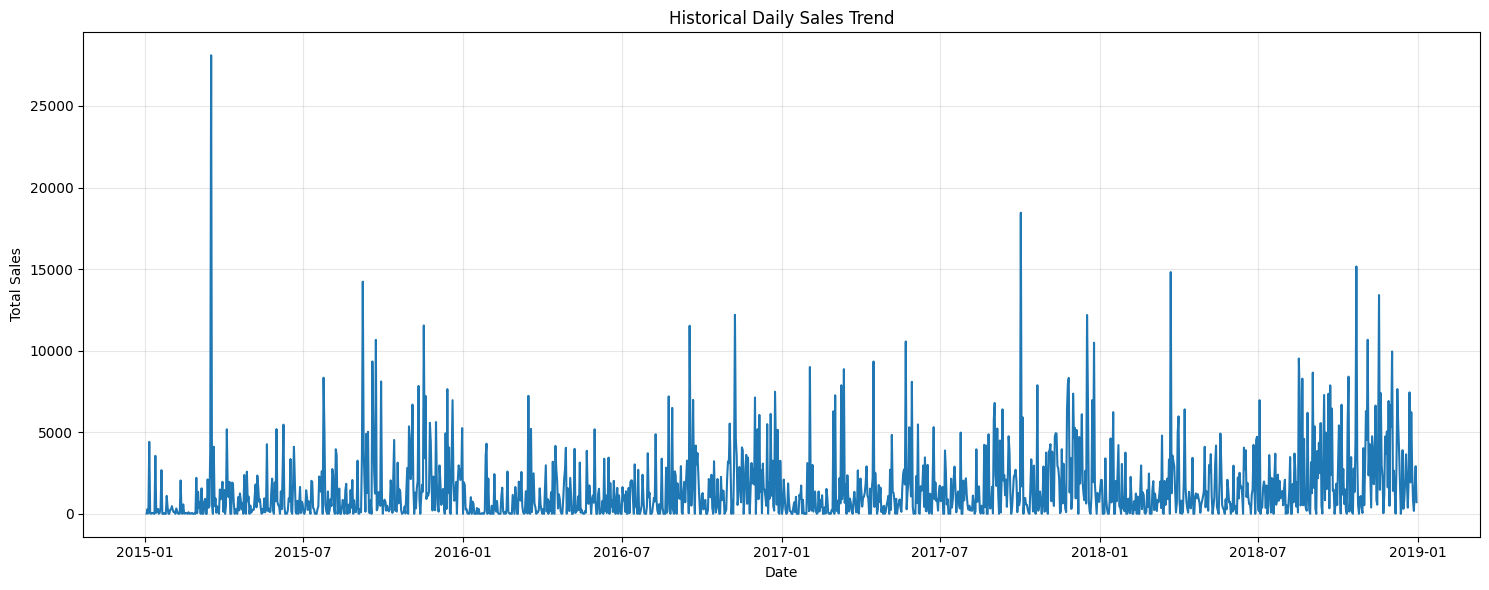

In [8]:
import matplotlib.pyplot as plt

# Create continuous daily date range
all_dates = pd.date_range(
    start=daily_sales["Date"].min(),
    end=daily_sales["Date"].max(),
    freq="D"
)

# Reindex daily sales to include all calendar days
daily_sales_full = (
    daily_sales
    .set_index("Date")
    .reindex(all_dates, fill_value=0)
    .rename_axis("Date")
    .reset_index()
)

print("========== DAILY TIME SERIES CHECK ==========\n")

print("Total Calendar Days:", len(daily_sales_full))
print("Days with Recorded Sales:", (daily_sales_full["Sales"] > 0).sum())
print("Days with No Sales:", (daily_sales_full["Sales"] == 0).sum())

# Plot historical daily sales trend
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales_full["Date"],
    daily_sales_full["Sales"]
)

plt.title("Historical Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Create monthly sales time series
monthly_sales = (
    df_clean
    .set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
    .reset_index()
)

# Rename columns
monthly_sales.columns = ["Date", "Sales"]

print("========== MONTHLY SALES TIME SERIES ==========\n")

print("Total Months:", len(monthly_sales))

print("\nFirst 12 Months:")
display(monthly_sales.head(12))

print("\nLast 12 Months:")
display(monthly_sales.tail(12))

print("\nMissing Months:", monthly_sales["Sales"].isnull().sum())

print("\n========== MONTHLY SALES SUMMARY ==========\n")

print("Total Sales:", f"${monthly_sales['Sales'].sum():,.2f}")
print("Average Monthly Sales:", f"${monthly_sales['Sales'].mean():,.2f}")
print("Highest Monthly Sales:", f"${monthly_sales['Sales'].max():,.2f}")
print("Lowest Monthly Sales:", f"${monthly_sales['Sales'].min():,.2f}")

print("\nMonthly sales dataset created successfully!")

========== MONTHLY SALES TIME SERIES ==========

Total Months: 48

First 12 Months:


,Date,Sales
0,2015-01-01,14205.7070
1,2015-02-01,4519.8920
2,2015-03-01,55205.7970
3,2015-04-01,27906.8550
4,2015-05-01,23644.3030
5,2015-06-01,34322.9356
6,2015-07-01,33781.5430
7,2015-08-01,27117.5365
8,2015-09-01,81623.5268
9,2015-10-01,31453.3930



Last 12 Months:


,Date,Sales
36,2018-01-01,43476.4740
37,2018-02-01,19920.9974
38,2018-03-01,58863.4128
39,2018-04-01,35541.9101
40,2018-05-01,43825.9822
41,2018-06-01,48190.7277
42,2018-07-01,44825.1040
43,2018-08-01,62837.8480
44,2018-09-01,86152.8880
45,2018-10-01,77448.1312



Missing Months: 0

========== MONTHLY SALES SUMMARY ==========

Total Sales: $2,261,536.78
Average Monthly Sales: $47,115.35
Highest Monthly Sales: $117,938.15
Lowest Monthly Sales: $4,519.89

Monthly sales dataset created successfully!


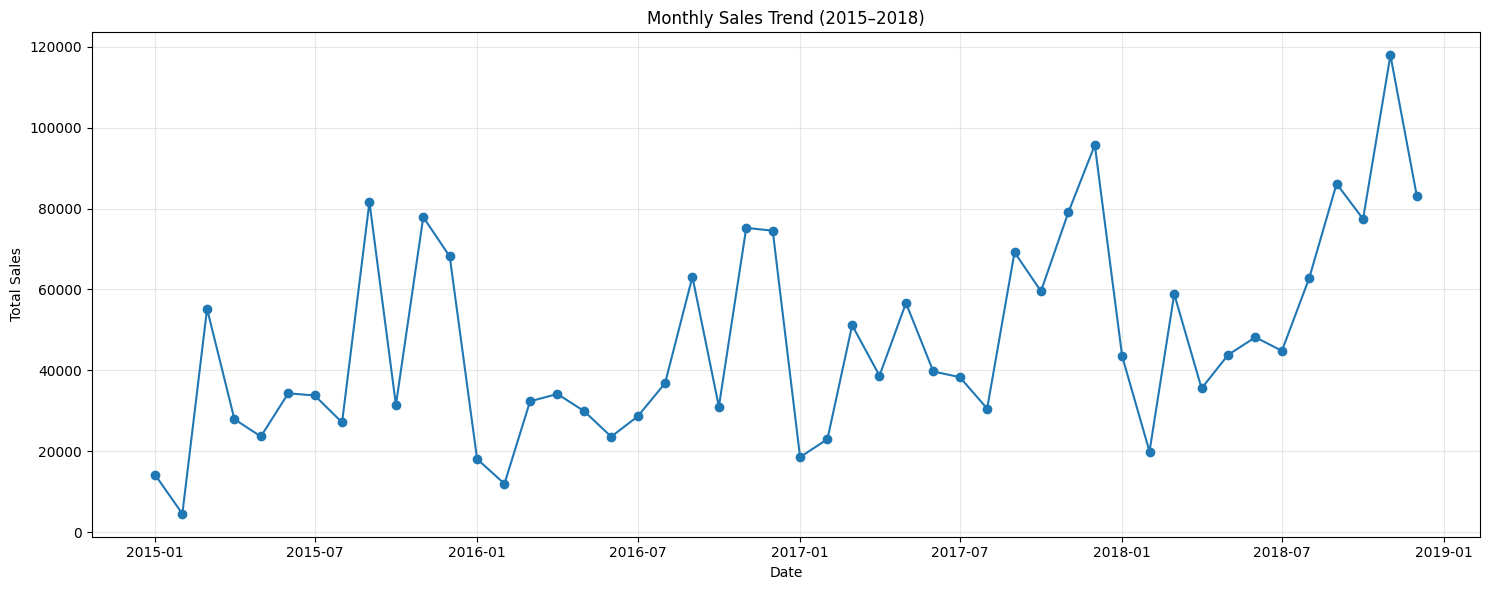

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

========== YEARLY SALES ==========



,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192



========== YEARLY GROWTH ==========



,Year,Sales,Growth %
0,2015,479856.2081,NaN
1,2016,459436.0054,-4.255484
2,2017,600192.5500,30.636812
3,2018,722052.0192,20.303396


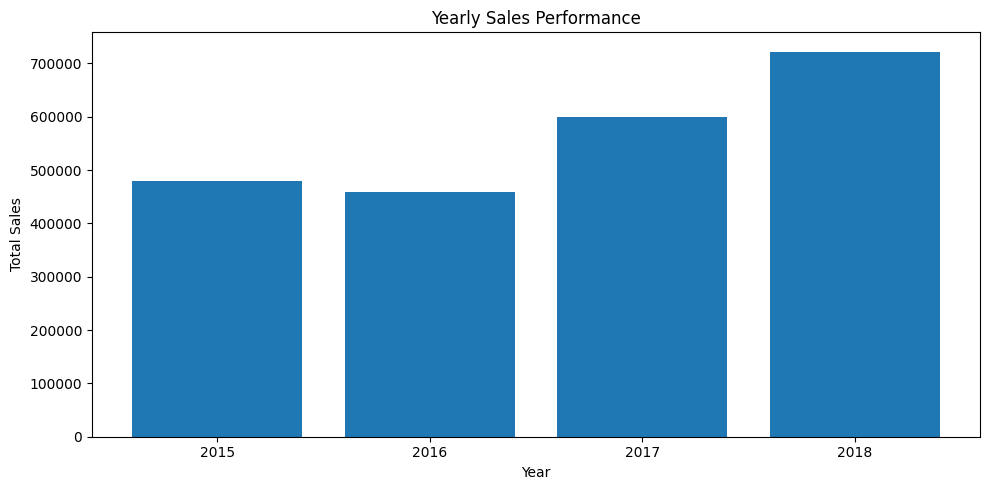

In [11]:
# Create Year column
monthly_sales["Year"] = monthly_sales["Date"].dt.year

# Calculate yearly sales
yearly_sales = (
    monthly_sales
    .groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

print("========== YEARLY SALES ==========\n")
display(yearly_sales)

# Calculate yearly growth
yearly_sales["Growth %"] = (
    yearly_sales["Sales"]
    .pct_change() * 100
)

print("\n========== YEARLY GROWTH ==========\n")
display(yearly_sales)

# Plot yearly sales
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Sales"]
)

plt.title("Yearly Sales Performance")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

========== MONTHLY SEASONALITY ==========



,Month Name,Sales
0,Jan,23572.907400
1,Feb,14842.778850
2,Mar,49393.396800
3,Apr,34070.750150
4,May,38521.680925
5,Jun,36459.380825
6,Jul,36383.922250
7,Aug,39328.981750
8,Sep,75025.852925
9,Oct,49874.073675


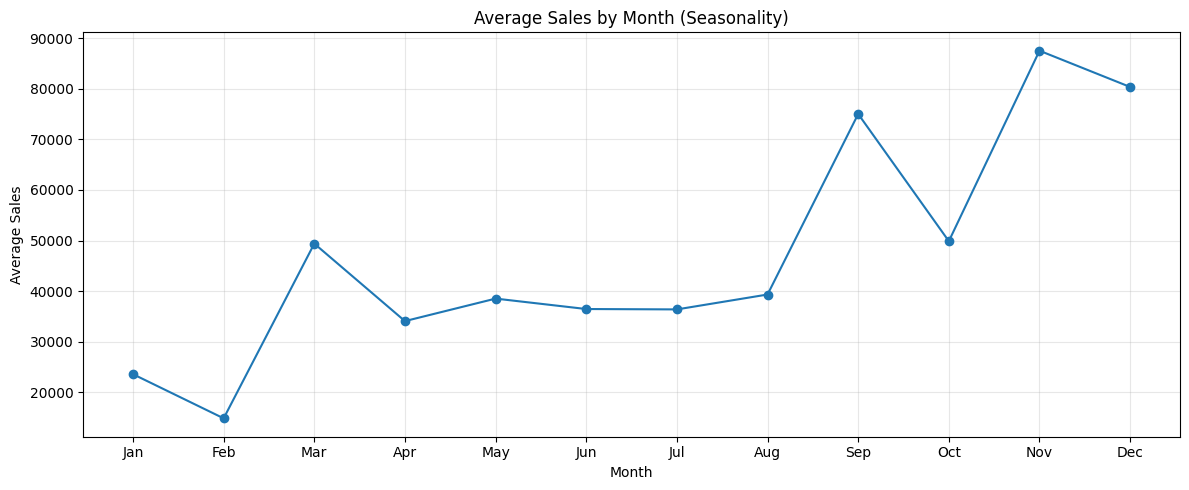

In [12]:
# Create Month column
monthly_sales["Month"] = monthly_sales["Date"].dt.month

# Average sales by calendar month
seasonality = (
    monthly_sales
    .groupby("Month")["Sales"]
    .mean()
    .reset_index()
)

# Month names
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

seasonality["Month Name"] = seasonality["Month"].apply(
    lambda x: month_names[x - 1]
)

print("========== MONTHLY SEASONALITY ==========\n")
display(seasonality[["Month Name", "Sales"]])

# Plot seasonality
plt.figure(figsize=(12, 5))

plt.plot(
    seasonality["Month Name"],
    seasonality["Sales"],
    marker="o"
)

plt.title("Average Sales by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print(monthly_sales.head())
print(monthly_sales.dtypes)


        Date      Sales  Year  Month
0 2015-01-01  14205.707  2015      1
1 2015-02-01   4519.892  2015      2
2 2015-03-01  55205.797  2015      3
3 2015-04-01  27906.855  2015      4
4 2015-05-01  23644.303  2015      5
Date     datetime64[ns]
Sales           float64
Year              int32
Month             int32
dtype: object


In [15]:
# ==========================================
# SET DATE AS TIME SERIES INDEX
# ==========================================

monthly_sales = monthly_sales.set_index('Date')

print("========== UPDATED MONTHLY SALES DATA ==========\n")
print(monthly_sales.head())

print("\nIndex type:", type(monthly_sales.index))

========== UPDATED MONTHLY SALES DATA ==========

                Sales  Year  Month
Date                              
2015-01-01  14205.707  2015      1
2015-02-01   4519.892  2015      2
2015-03-01  55205.797  2015      3
2015-04-01  27906.855  2015      4
2015-05-01  23644.303  2015      5

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [16]:
# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("========== TRAIN-TEST SPLIT ==========\n")

print(f"Training Period: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')}")
print(f"Testing Period: {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')}")

print(f"\nTraining Months: {len(train)}")
print(f"Testing Months: {len(test)}")

========== TRAIN-TEST SPLIT ==========

Training Period: 2015-01 to 2017-12
Testing Period: 2018-01 to 2018-12

Training Months: 36
Testing Months: 12


In [17]:
# ==========================================
# NAIVE FORECAST BASELINE MODEL
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create naive forecast
naive_forecast = pd.Series(
    [train['Sales'].iloc[-1]] * len(test),
    index=test.index
)

print("========== NAIVE FORECAST ==========\n")

comparison = pd.DataFrame({
    'Actual Sales': test['Sales'],
    'Naive Forecast': naive_forecast
})

print(comparison)

========== NAIVE FORECAST ==========

            Actual Sales  Naive Forecast
Date                                    
2018-01-01    43476.4740       95739.121
2018-02-01    19920.9974       95739.121
2018-03-01    58863.4128       95739.121
2018-04-01    35541.9101       95739.121
2018-05-01    43825.9822       95739.121
2018-06-01    48190.7277       95739.121
2018-07-01    44825.1040       95739.121
2018-08-01    62837.8480       95739.121
2018-09-01    86152.8880       95739.121
2018-10-01    77448.1312       95739.121
2018-11-01   117938.1550       95739.121
2018-12-01    83030.3888       95739.121


In [18]:
# ==========================================
# NAIVE FORECAST EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(
    test['Sales'],
    naive_forecast
)

rmse_naive = np.sqrt(
    mean_squared_error(
        test['Sales'],
        naive_forecast
    )
)

mape_naive = np.mean(
    np.abs(
        (test['Sales'] - naive_forecast) / test['Sales']
    )
) * 100


print("========== NAIVE MODEL PERFORMANCE ==========\n")

print(f"MAE  : {mae_naive:,.2f}")
print(f"RMSE : {rmse_naive:,.2f}")
print(f"MAPE : {mape_naive:.2f}%")

========== NAIVE MODEL PERFORMANCE ==========

MAE  : 39,267.96
RMSE : 43,945.62
MAPE : 98.73%


In [19]:
# ==========================================
# ARIMA MODEL
# ==========================================

from statsmodels.tsa.arima.model import ARIMA

# Build the ARIMA model
arima_model = ARIMA(
    train['Sales'],
    order=(1, 1, 1)
)

# Train the model
arima_results = arima_model.fit()

print("========== ARIMA MODEL TRAINED ==========\n")

print(arima_results.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


========== ARIMA MODEL TRAINED ==========

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -401.290
Date:                Mon, 07 Sep 2026   AIC                            808.579
Time:                        15:06:12   BIC                            813.245
Sample:                    01-01-2015   HQIC                           810.190
                         - 12-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1500      0.286      0.524      0.600      -0.411       0.711
ma.L1         -0.7770      0.166     -4.668      0.000      -1.103      -0.451
sigma2   

In [20]:
# ==========================================
# ARIMA FORECAST
# ==========================================

# Forecast the next 12 months
arima_forecast = arima_results.forecast(steps=len(test))

# Create comparison DataFrame
arima_comparison = pd.DataFrame({
    'Actual Sales': test['Sales'],
    'ARIMA Forecast': arima_forecast
})

print("========== ARIMA FORECAST ==========\n")

print(arima_comparison)

========== ARIMA FORECAST ==========

            Actual Sales  ARIMA Forecast
2018-01-01    43476.4740    70808.434816
2018-02-01    19920.9974    67068.797168
2018-03-01    58863.4128    66507.846313
2018-04-01    35541.9101    66423.702904
2018-05-01    43825.9822    66411.081275
2018-06-01    48190.7277    66409.188013
2018-07-01    44825.1040    66408.904021
2018-08-01    62837.8480    66408.861422
2018-09-01    86152.8880    66408.855032
2018-10-01    77448.1312    66408.854074
2018-11-01   117938.1550    66408.853930
2018-12-01    83030.3888    66408.853908


In [21]:
# ==========================================
# ARIMA MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae_arima = mean_absolute_error(
    test['Sales'],
    arima_forecast
)

# RMSE
rmse_arima = np.sqrt(
    mean_squared_error(
        test['Sales'],
        arima_forecast
    )
)

# MAPE
mape_arima = np.mean(
    np.abs(
        (test['Sales'] - arima_forecast) / test['Sales']
    )
) * 100


print("========== ARIMA MODEL PERFORMANCE ==========\n")

print(f"MAE  : {mae_arima:,.2f}")
print(f"RMSE : {rmse_arima:,.2f}")
print(f"MAPE : {mape_arima:.2f}%")

========== ARIMA MODEL PERFORMANCE ==========

MAE  : 23,158.21
RMSE : 26,996.79
MAPE : 53.62%


In [22]:
# ==========================================
# SARIMA MODEL
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA model
sarima_model = SARIMAX(
    train['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train the model
sarima_results = sarima_model.fit(disp=False)

print("========== SARIMA MODEL TRAINED ==========\n")

print(sarima_results.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


========== SARIMA MODEL TRAINED ==========

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -96.483
Date:                            Mon, 07 Sep 2026   AIC                            202.966
Time:                                    15:09:02   BIC                            203.952
Sample:                                01-01-2015   HQIC                           200.838
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2270      0.644     -0.352      0.725      -1.489    

In [23]:
# ==========================================
# SARIMA FORECAST
# ==========================================

# Forecast the next 12 months
sarima_forecast = sarima_results.forecast(steps=len(test))

# Create comparison DataFrame
sarima_comparison = pd.DataFrame({
    'Actual Sales': test['Sales'],
    'SARIMA Forecast': sarima_forecast
})

print("========== SARIMA FORECAST ==========\n")

print(sarima_comparison)

========== SARIMA FORECAST ==========

            Actual Sales  SARIMA Forecast
2018-01-01    43476.4740     27975.796262
2018-02-01    19920.9974     34827.155926
2018-03-01    58863.4128     63496.319640
2018-04-01    35541.9101     49788.562543
2018-05-01    43825.9822     68264.672590
2018-06-01    48190.7277     51284.731171
2018-07-01    44825.1040     49491.182796
2018-08-01    62837.8480     40827.461395
2018-09-01    86152.8880     80801.967292
2018-10-01    77448.1312     71137.522359
2018-11-01   117938.1550     90369.066811
2018-12-01    83030.3888    107464.423765


In [24]:
# ==========================================
# SARIMA MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae_sarima = mean_absolute_error(
    test['Sales'],
    sarima_forecast
)

# RMSE
rmse_sarima = np.sqrt(
    mean_squared_error(
        test['Sales'],
        sarima_forecast
    )
)

# MAPE
mape_sarima = np.mean(
    np.abs(
        (test['Sales'] - sarima_forecast) / test['Sales']
    )
) * 100


print("========== SARIMA MODEL PERFORMANCE ==========\n")

print(f"MAE  : {mae_sarima:,.2f}")
print(f"RMSE : {rmse_sarima:,.2f}")
print(f"MAPE : {mape_sarima:.2f}%")

========== SARIMA MODEL PERFORMANCE ==========

MAE  : 13,930.02
RMSE : 16,394.82
MAPE : 27.77%


In [25]:
# ==========================================
# MODEL PERFORMANCE COMPARISON
# ==========================================

model_comparison = pd.DataFrame({
    'Model': ['Naive', 'ARIMA', 'SARIMA'],
    'MAE': [mae_naive, mae_arima, mae_sarima],
    'RMSE': [rmse_naive, rmse_arima, rmse_sarima],
    'MAPE (%)': [mape_naive, mape_arima, mape_sarima]
})

print("========== MODEL PERFORMANCE COMPARISON ==========\n")
print(model_comparison.round(2))

========== MODEL PERFORMANCE COMPARISON ==========

    Model       MAE      RMSE  MAPE (%)
0   Naive  39267.96  43945.62     98.73
1   ARIMA  23158.21  26996.79     53.62
2  SARIMA  13930.02  16394.82     27.77


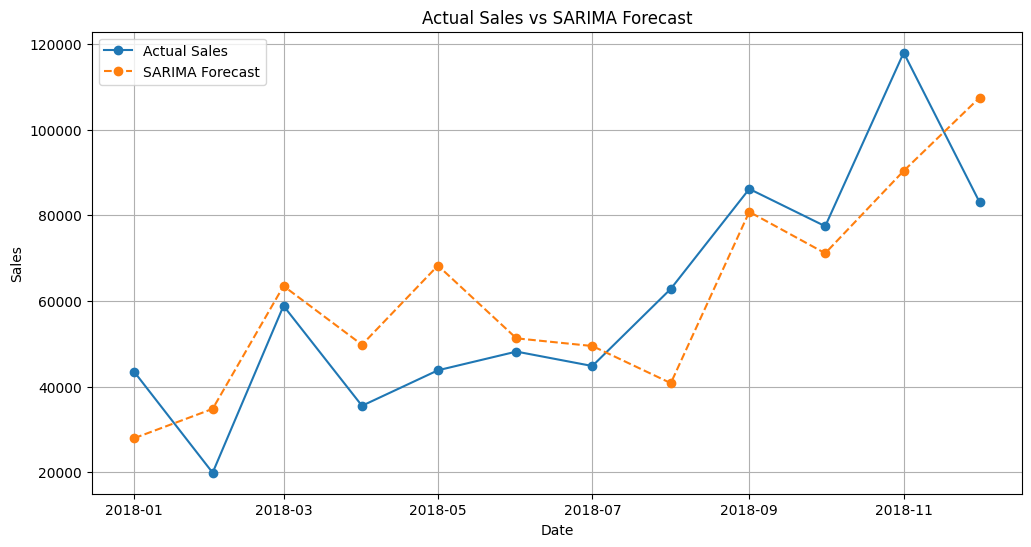

In [26]:
# ==========================================
# ACTUAL VS SARIMA FORECAST
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test['Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    test.index,
    sarima_forecast,
    marker='o',
    linestyle='--',
    label='SARIMA Forecast'
)

plt.title('Actual Sales vs SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# ==========================================
# FINAL SARIMA MODEL - FUTURE FORECAST
# ==========================================

final_sarima_model = SARIMAX(
    monthly_sales['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_results = final_sarima_model.fit(disp=False)

# Forecast next 12 months
future_forecast = final_sarima_results.forecast(steps=12)

print("========== NEXT 12 MONTHS SALES FORECAST ==========\n")

print(future_forecast)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


========== NEXT 12 MONTHS SALES FORECAST ==========

2019-01-01     46782.479190
2019-02-01     40285.470524
2019-03-01     72234.203233
2019-04-01     57236.029435
2019-05-01     66910.825701
2019-06-01     61378.253169
2019-07-01     60193.673075
2019-08-01     64798.240310
2019-09-01     95640.888341
2019-10-01     81551.123515
2019-11-01    113342.880727
2019-12-01    106094.284728
Freq: MS, Name: predicted_mean, dtype: float64


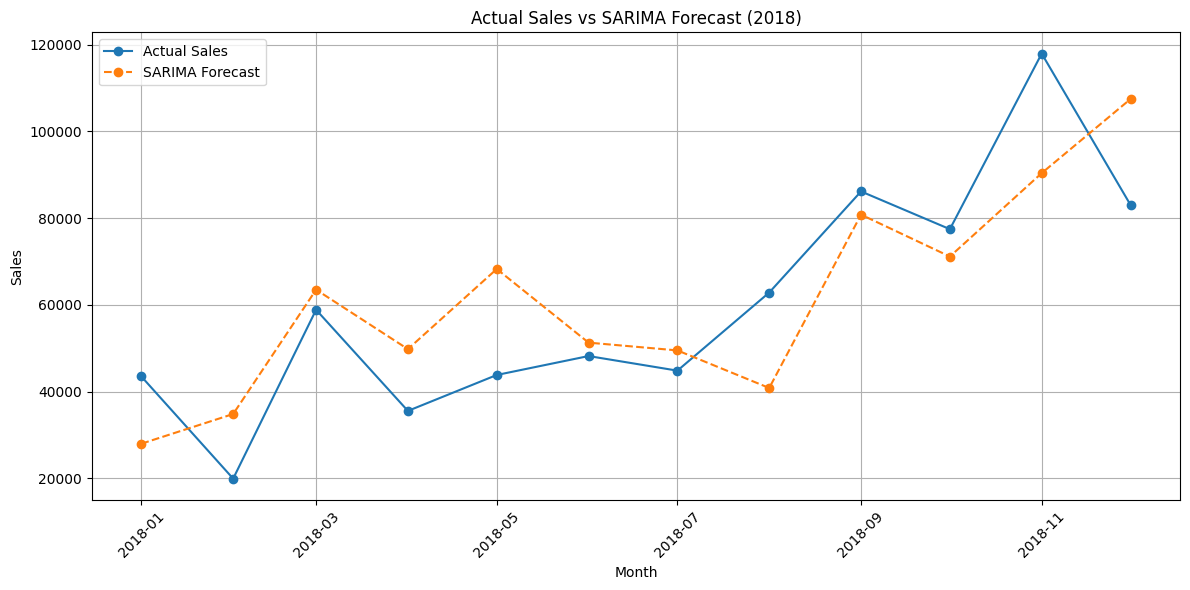

In [28]:
# ==========================================
# VISUALIZATION 1: ACTUAL VS SARIMA FORECAST
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    test.index,
    test['Sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    test.index,
    sarima_forecast,
    marker='o',
    linestyle='--',
    label='SARIMA Forecast'
)

plt.title('Actual Sales vs SARIMA Forecast (2018)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

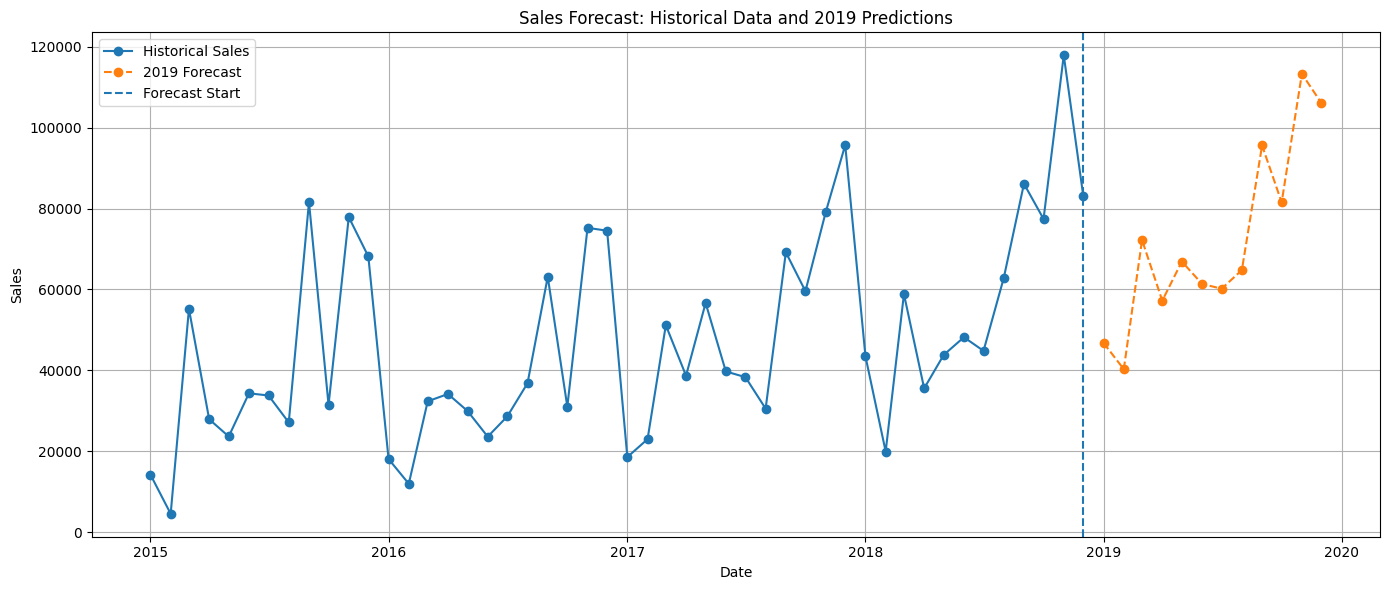

In [29]:
# ==========================================
# VISUALIZATION 2: HISTORICAL + FUTURE FORECAST
# ==========================================

plt.figure(figsize=(14, 6))

# Historical sales
plt.plot(
    monthly_sales.index,
    monthly_sales['Sales'],
    marker='o',
    label='Historical Sales'
)

# Future forecast
plt.plot(
    future_forecast.index,
    future_forecast,
    marker='o',
    linestyle='--',
    label='2019 Forecast'
)

# Separate historical and forecast periods
plt.axvline(
    monthly_sales.index[-1],
    linestyle='--',
    label='Forecast Start'
)

plt.title('Sales Forecast: Historical Data and 2019 Predictions')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# SAVE FUTURE SALES FORECAST
# ==========================================

future_forecast_df = pd.DataFrame({
    'Date': future_forecast.index,
    'Forecasted_Sales': future_forecast.values
})

future_forecast_df.to_csv(
    '/content/future_sales_forecast.csv',
    index=False
)

print("Future forecast saved successfully!")

Future forecast saved successfully!


In [31]:
from google.colab import files

files.download('/content/future_sales_forecast.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>